Importing dependencies

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

Load CSV

In [3]:
df = pd.read_csv("../dataset/kenya.csv", encoding='latin1', skiprows=[1])
print(df.shape)
df.head()

(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05


Add country column

In [4]:
df["Country"] = "Kenya"


Convert YEAR + DOY → Date

In [5]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

Extract Month

In [6]:
df["Month"] = df["Date"].dt.month


Data cleaning and summary statistics

In [7]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05,Kenya,2015-01-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4103,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4104,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4105,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


In [8]:
df["Month"] = df["Date"].dt.month

In [ ]:
df[["Date", "Month"]].head()

,Date,Month
0,2015-01-02,1
1,2015-01-03,1
2,2015-01-04,1
3,2015-01-05,1
4,2015-01-06,1


In [9]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


Duplicate rows

No duplicate rows were found in the dataset (0 duplicates). 
This indicates that each observation is unique, and no data cleaning was required for duplicates.

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027,NaN,3.476439


Missing values count

In [11]:
missing_counts = df.isna().sum()
missing_counts

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

Missing percentage

In [12]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

In [13]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

Missing values analysis
After replacing sentinel values (-999) with NaN, the dataset was checked for missing values.

No column has more than 5% missing data. This indicates that the dataset is relatively complete and suitable for analysis without significant data loss.

Minor missing values (if any) are unlikely to significantly affect the overall results.

●	Outlier Detection & Basic Cleaning

compute Z-scores

In [14]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

outlier_count

np.int64(120)

Outlier detection & handling decision

Outliers were identified using the Z-score method, where any observation with |Z| > 3 was considered an outlier.

A total of **120 rows** were flagged as outliers across the selected climate variables.

This indicates the presence of extreme values in the dataset, which may correspond to real-world climate events.
In climate datasets, extreme values are often meaningful and represent actual environmental phenomena such as extreme temperatures, storms, or unusual weather conditions. Removing these values could lead to loss of important information and bias the analysis.

Therefore, all outlier observations were preserved for further analysis.

In [15]:
df[cols] = df[cols].ffill()

In [16]:
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

In [17]:
df.to_csv("../dataset/kenya_clean.csv", index=False)

●	Time Series Analysis

Monthly Average Temperature

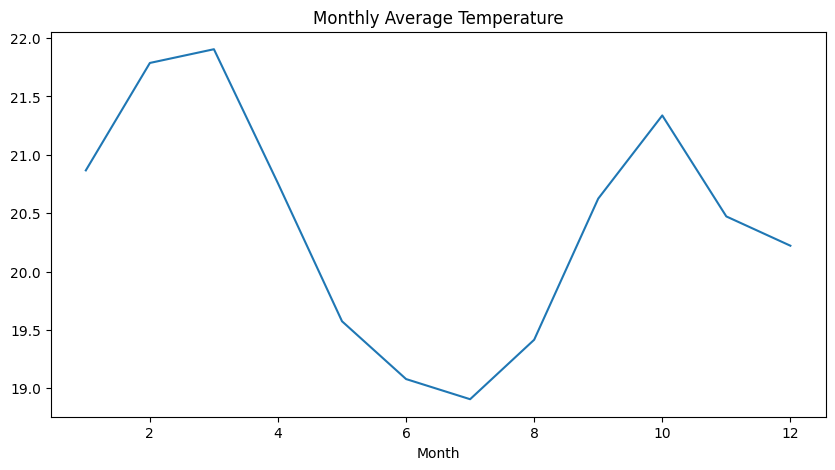

In [18]:
monthly_temp = df.groupby("Month")["T2M"].mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.show()

# Temperature trend
The plot shows monthly average temperature patterns. Warmer months appear around (X), while cooler months occur around (Y).

Rainfall bar chart

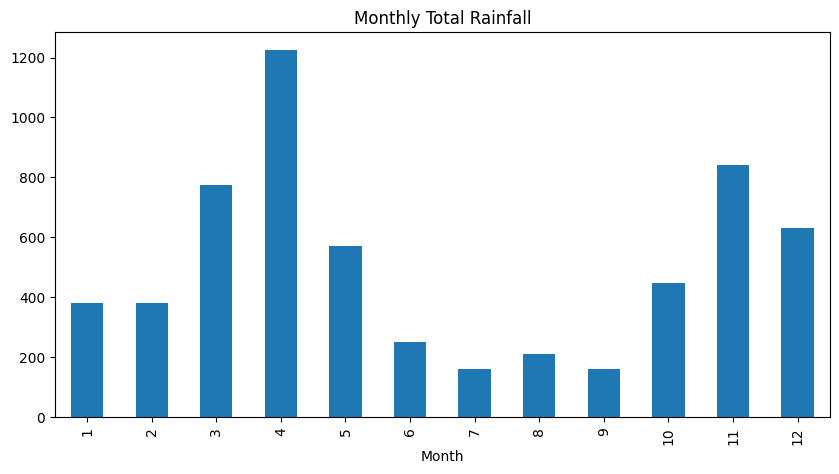

In [19]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

# Rainfall Patterns

Rainfall peaks during (X months), indicating the rainy season.

●	Correlation & Relationship Analysis

Heatmap

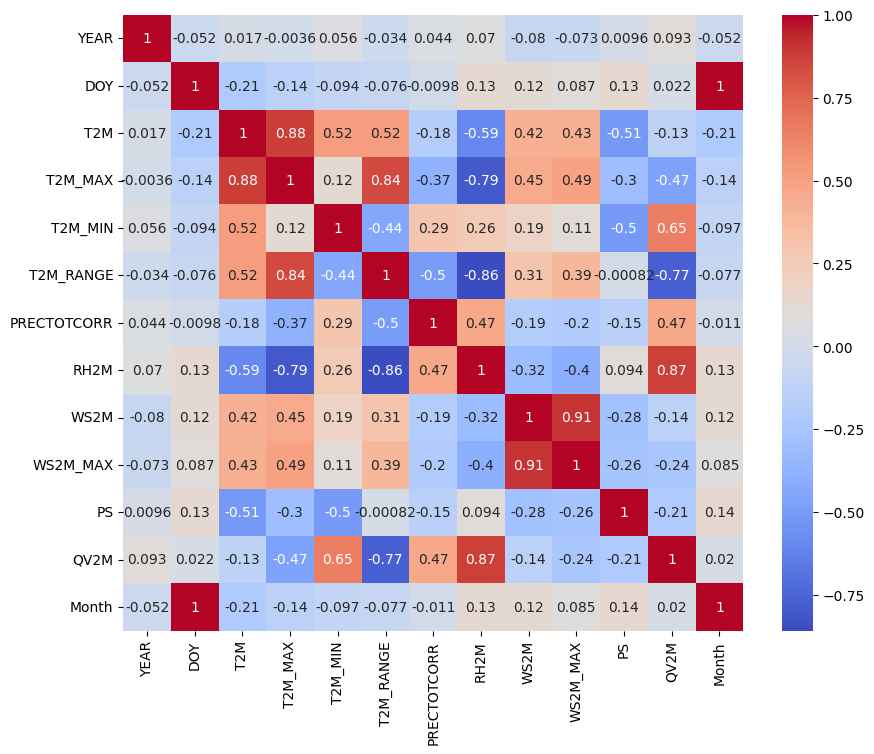

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Scatter Plots

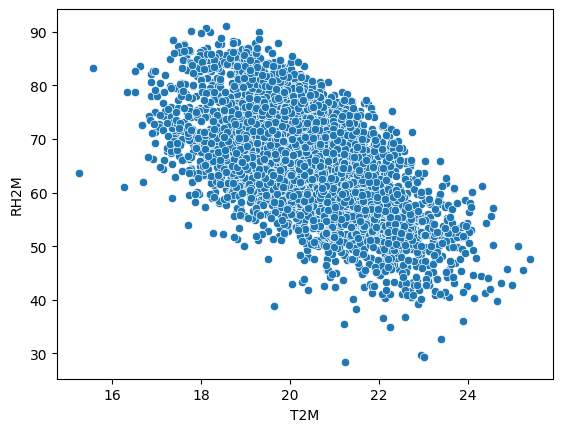

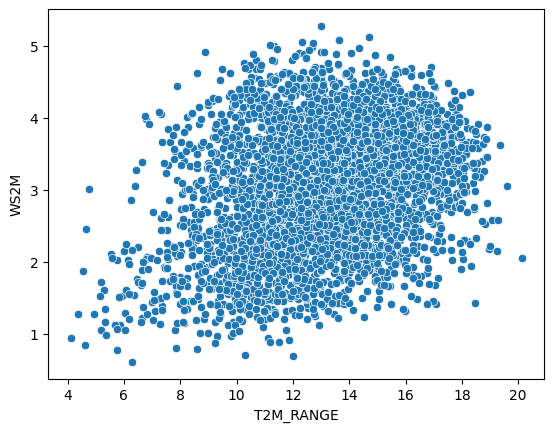

In [21]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

# Scatter Plot Interpretations
T2M vs. RH2M: Shows a weak negative correlation. As temperature ($T2M$) increases, relative humidity ($RH2M$) generally tends to decrease, though the high density of points suggests many other factors are at play.

T2M_RANGE vs. WS2M: Shows a weak positive correlation. A wider daily temperature range often coincides with slightly higher wind speeds, likely due to increased thermal turbulence.

# Three Strongest Potential Correlations
T2M & T2M_MAX/MIN (Strong Positive): Average temperature is mathematically and physically tied to its daily highs and lows.

T2M_RANGE & RH2M (Strong Negative): High temperature swings typically occur in dry environments (low humidity) where the air loses heat quickly at night.

PRECTOTCORR & RH2M (Moderate Positive): High precipitation is almost always coupled with high humidity levels.

# Distribution Analysis

Histogram

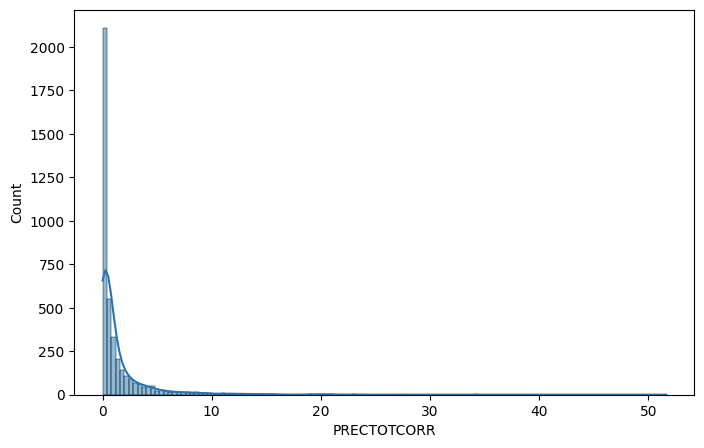

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.show()

Histogram Analysis

Distribution Shape: The data is heavily right-skewed. The vast majority of observations are at or near zero (dry days), with a long "tail" representing rare, high-precipitation events.

Bubble Chart

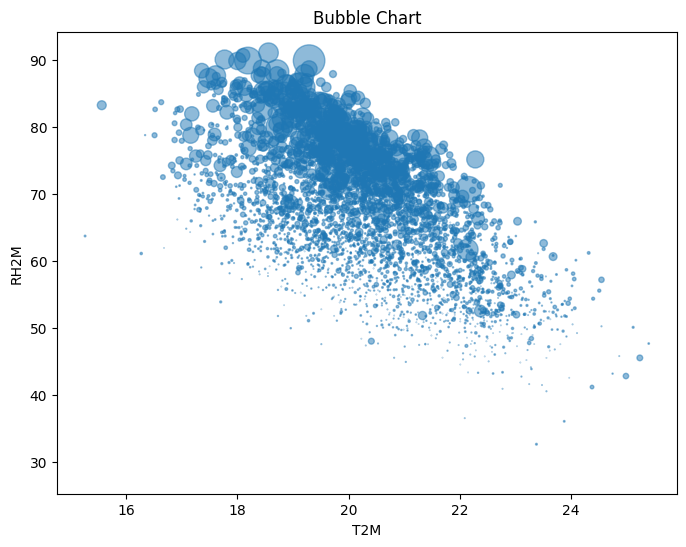

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Bubble Chart")
plt.show()